In [43]:
#Notebook for EDA of data, model performance and model outputs
import pandas as pd
from google import genai
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import os
import lightgbm as lgb
pd.set_option('display.max_rows', None)

In [44]:
# load_dotenv()
# api_key = os.environ.get("GEMINI_API_KEY")
# client = genai.Client()

# response = client.models.generate_content(model = "gemini-2.5-flash", contents="Explain how I can create a MSC project which detects AI in traffic flow stastical data for wifi? this is a data science project")

# print(response.text)

In [45]:
#Find dataset path
path = "../Datastore/processed_datasets/dataset_windowed.csv"
print(os.path.exists(path))
print(os.getcwd())

True
e:\AS9Wa\MSc Thesis\AgenticVision\EDA notebooks


In [46]:
#Import and drop duplicate class label
df = pd.read_csv(path)
df = df.drop(columns=["label_model"])
df.head()

,session_id,label_llm,label_workload,win_idx,flow_elapsed_s,flow_position_norm,pkt_count,fwd_count,bwd_count,fwd_bwd_pkt_ratio,...,delta_byte_growth_r2,delta_byte_growth_residual_std,delta_tok_iat_mean,delta_tok_iat_std,delta_tok_iat_p50,delta_tok_iat_ac_lag1,delta_tok_rate,delta_tok_iat_cv,bytes_per_token,iat_tok_pkt_ratio
0,58cb5f85,groq_qwen3_32b,short_factual,0,0.0,0.0000,3.0,1.0,2.0,0.5000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0000,0.0,0.0000,5.69,0.0055
1,58cb5f85,groq_qwen3_32b,short_factual,1,0.1,0.0249,2.0,1.0,1.0,1.0000,...,0.0,0.0,-0.000340,-0.000965,-0.000083,0.0032,50.0,0.4534,3.89,0.0000
2,58cb5f85,groq_qwen3_32b,short_factual,2,0.2,0.0499,2.0,1.0,1.0,1.0000,...,0.0,0.0,-0.000045,-0.000143,-0.000003,-0.0006,8.0,0.0635,3.82,0.0000
3,58cb5f85,groq_qwen3_32b,short_factual,3,0.3,0.0748,2.0,1.0,1.0,1.0000,...,0.0,0.0,-0.000954,-0.012822,0.000002,-0.0445,50.0,-5.0194,3.43,0.0000
4,58cb5f85,groq_qwen3_32b,short_factual,4,0.4,0.0998,10.0,1.0,9.0,0.1111,...,0.0,0.0,0.000000,0.000000,0.000000,0.0000,0.0,0.0000,9.57,0.0258


In [47]:
#Print percentage of rows where values are 0 or nan:
summary = pd.DataFrame({
    'Percent_Zero_or_NaN': (((df == 0) | (df.isna())).mean() * 100).round(2),
    'Zero_Count': (df == 0).sum(),
    'NaN_Count': df.isna().sum(),
    'Total_Rows': len(df)
}).sort_values('Percent_Zero_or_NaN', ascending=False)

print(summary)

                                Percent_Zero_or_NaN  Zero_Count  NaN_Count  \
delta_iat_ac_lag1                            100.00        9681          0   
delta_pktlen_mean                            100.00        9681          0   
delta_iat_p95                                100.00        9681          0   
delta_iat_std                                100.00        9681          0   
delta_bwd_iat_mean                           100.00        9681          0   
delta_bwd_iat_std                            100.00        9681          0   
delta_bwd_iat_ac_lag1                        100.00        9681          0   
delta_iat_mean                               100.00        9681          0   
delta_iat_p50                                100.00        9681          0   
delta_pktlen_entropy                         100.00        9681          0   
delta_throughput_bps                         100.00        9681          0   
delta_byte_ratio_bwd_fwd                     100.00        9681 

In [39]:
#Remove columns where 95% or more are 0 or missing values
df = df.drop(columns=summary[summary['Percent_Zero_or_NaN'] > 95].index)
df = df.drop(columns=["tls_detected"]) # coolumn with all 1s. all TLS Traffic, therefore no variance.

In [40]:
#Run correlation matrix too identify any highly correlated, duplicate features
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,win_idx,flow_elapsed_s,flow_position_norm,pkt_count,fwd_count,bwd_count,fwd_bwd_pkt_ratio,total_bytes,fwd_bytes,bwd_bytes,...,tok_rate,tok_iat_cv,delta_tok_iat_mean,delta_tok_iat_std,delta_tok_iat_p50,delta_tok_iat_ac_lag1,delta_tok_rate,delta_tok_iat_cv,bytes_per_token,iat_tok_pkt_ratio
win_idx,1.000000,1.000000,0.478070,-0.011978,-0.128110,0.012732,-0.196315,-0.027284,-0.150959,-0.021364,...,-0.272396,-0.199763,0.036027,0.000229,0.033919,0.026297,-0.062126,-0.017286,-0.077334,-0.020541
flow_elapsed_s,1.000000,1.000000,0.478070,-0.011978,-0.128110,0.012732,-0.196315,-0.027284,-0.150959,-0.021364,...,-0.272396,-0.199763,0.036027,0.000229,0.033919,0.026297,-0.062126,-0.017286,-0.077334,-0.020541
flow_position_norm,0.478070,0.478070,1.000000,0.052887,-0.073307,0.071146,-0.245010,0.048397,-0.115688,0.054036,...,-0.505458,-0.349755,-0.188448,-0.139292,-0.168862,0.154677,-0.258682,-0.279900,-0.083585,-0.032447
pkt_count,-0.011978,-0.011978,0.052887,1.000000,0.428062,0.983641,0.075166,0.943199,0.403336,0.941210,...,0.218246,0.131670,0.069097,0.001672,0.067153,0.060028,-0.156234,-0.014043,0.145656,-0.008970
fwd_count,-0.128110,-0.128110,-0.073307,0.428062,1.000000,0.258258,0.483424,0.417111,0.980034,0.382490,...,0.196753,0.136289,0.044249,0.021336,0.040358,-0.031880,0.004473,0.044853,0.119313,-0.005700
bwd_count,0.012732,0.012732,0.071146,0.983641,0.258258,1.000000,-0.016008,0.925105,0.235807,0.929880,...,0.194080,0.113585,0.065043,-0.002466,0.063740,0.070522,-0.167900,-0.023951,0.131919,-0.008453
fwd_bwd_pkt_ratio,-0.196315,-0.196315,-0.245010,0.075166,0.483424,-0.016008,1.000000,0.090946,0.561812,0.068745,...,0.166503,0.148056,0.015209,0.024416,0.008048,-0.085910,0.115189,0.088620,0.095231,-0.002876
total_bytes,-0.027284,-0.027284,0.048397,0.943199,0.417111,0.925105,0.090946,1.000000,0.395279,0.999252,...,0.196287,0.132257,0.068120,-0.015665,0.070491,0.050991,-0.165872,-0.056817,0.164698,-0.007955
fwd_bytes,-0.150959,-0.150959,-0.115688,0.403336,0.980034,0.235807,0.561812,0.395279,1.000000,0.359471,...,0.211370,0.149049,0.050635,0.023454,0.046104,-0.039759,0.013617,0.050536,0.121436,-0.005265
bwd_bytes,-0.021364,-0.021364,0.054036,0.941210,0.382490,0.929880,0.068745,0.999252,0.359471,1.000000,...,0.190509,0.128085,0.067071,-0.016901,0.069671,0.053474,-0.169080,-0.059847,0.162204,-0.007859


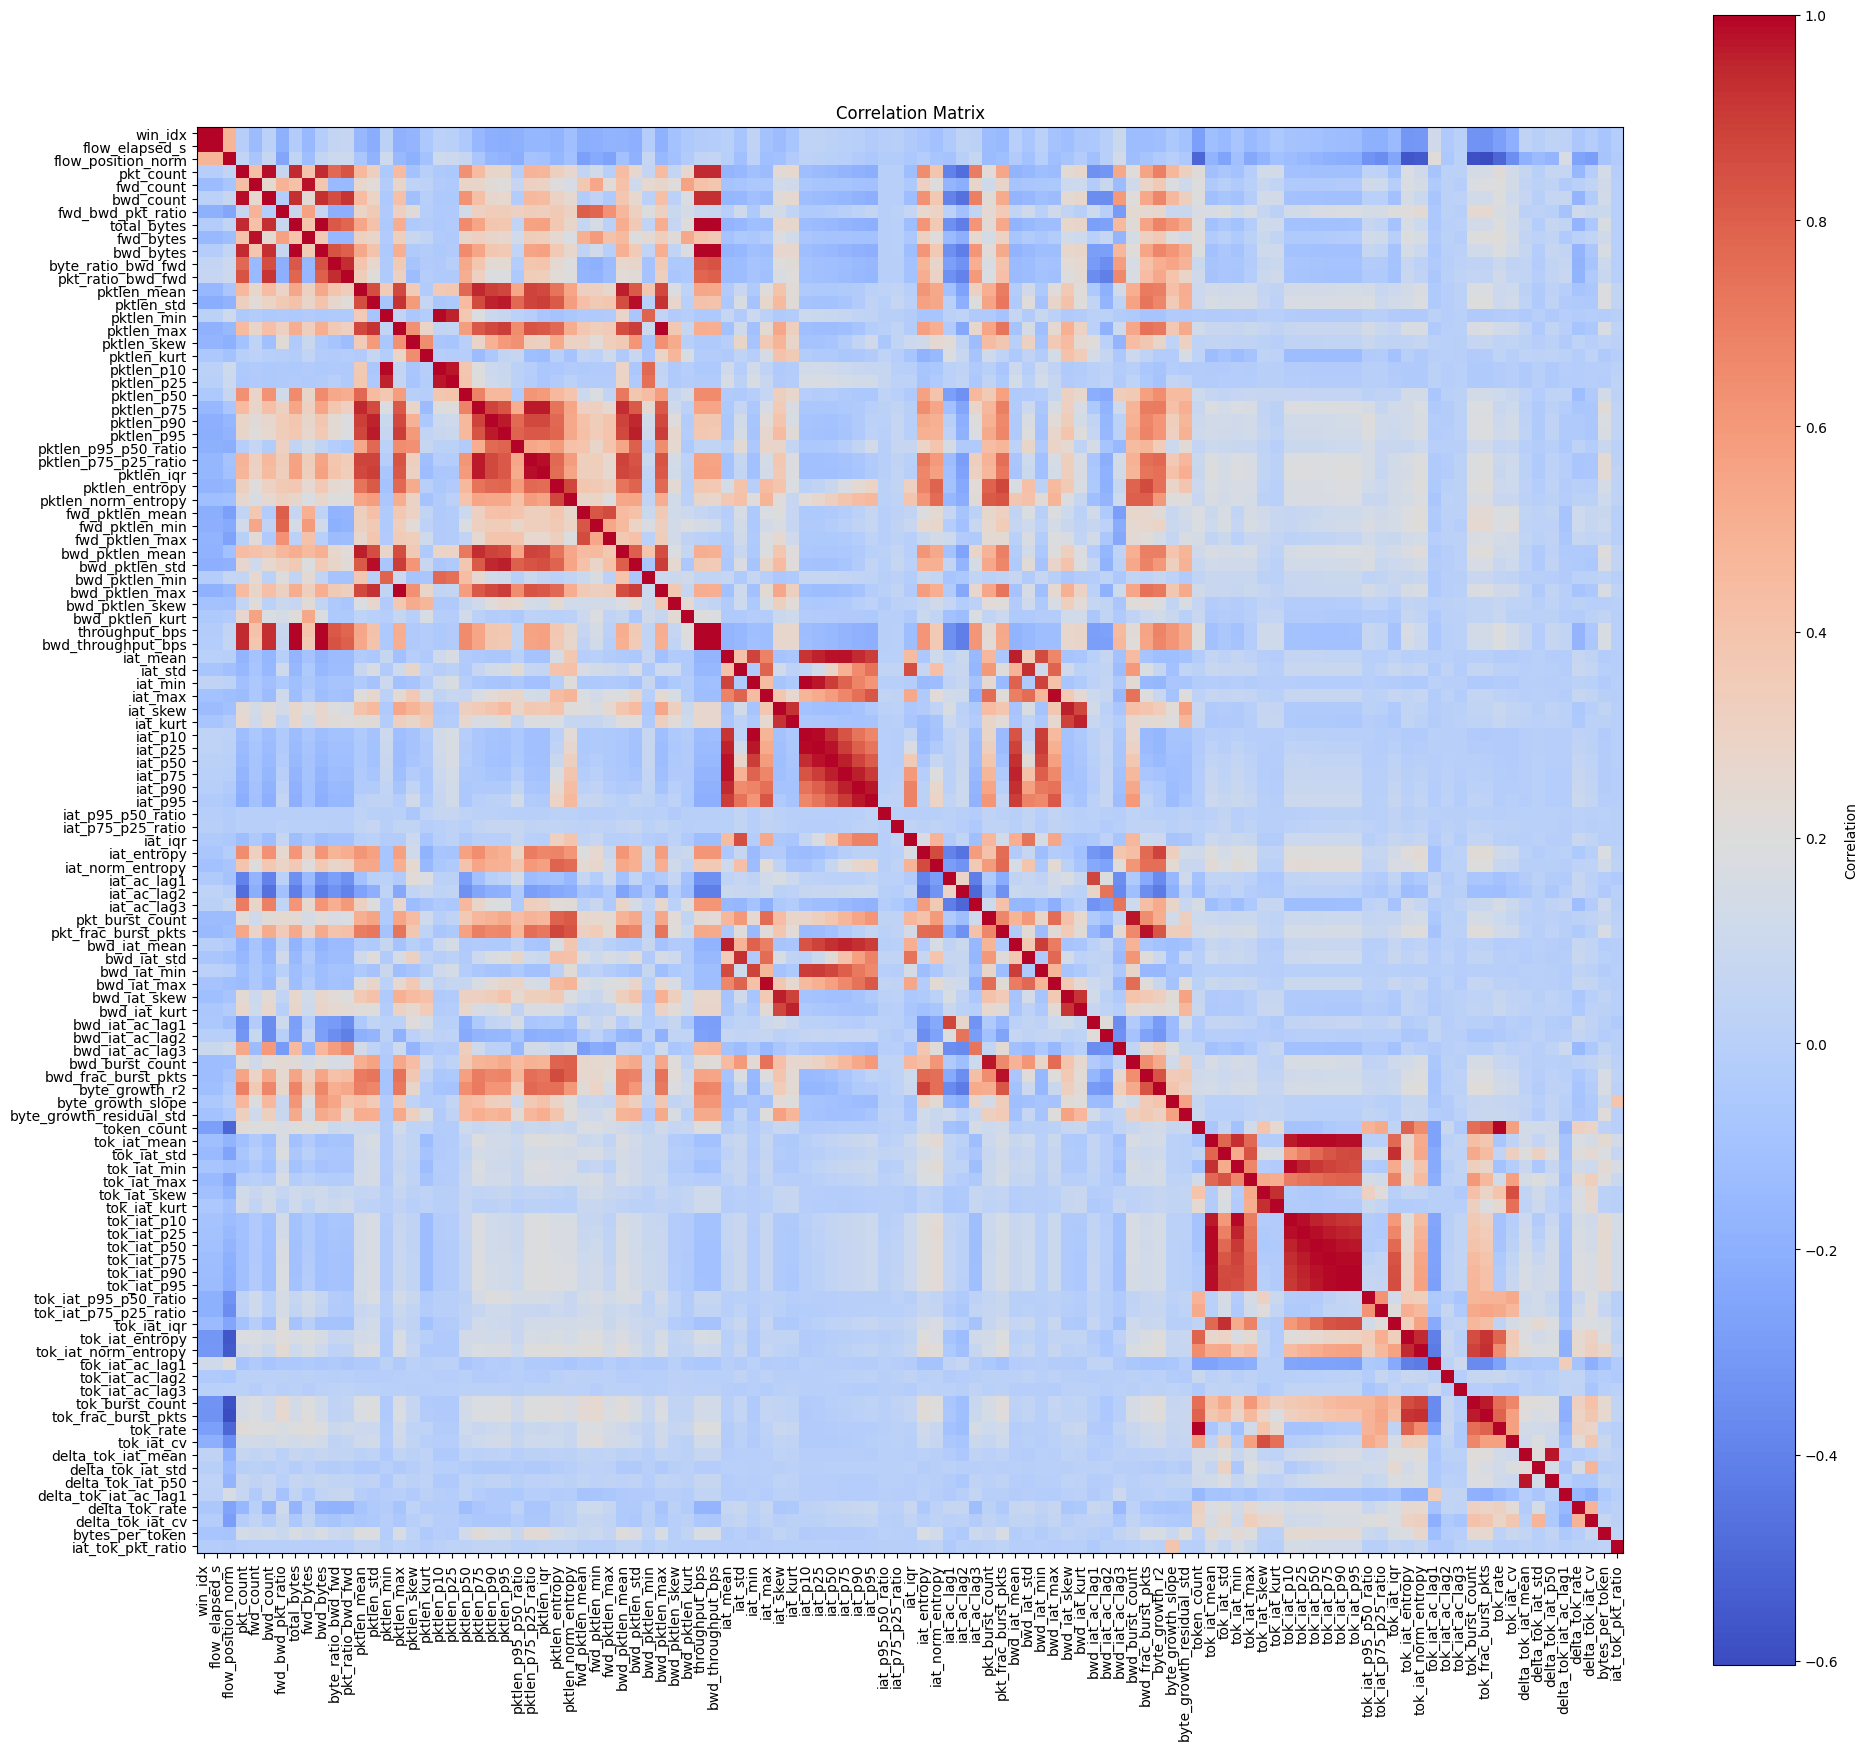

In [ ]:
#Plot Corr matrix as a table:
plt.figure(figsize=(20, 18))

plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()